# Week 1 Lab — Python, NumPy, Pandas & Matplotlib

This notebook contains the 25 graded tasks from the Week 1 lab manual.  
Each question has a short note, code, and output.

The solutions use straightforward Python/NumPy/Pandas/Matplotlib rather than overly complicated approaches.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Q1 — Swap two variables

I can swap the values directly using Python tuple unpacking, so no third variable is needed.

In [2]:
a = 10
b = 25

a, b = b, a

print("a =", a)
print("b =", b)

a = 25
b = 10


## Q2 — Check whether a number is prime

A prime number has no divisor other than 1 and itself. I only need to check divisors up to the square root of the number.

In [3]:
def is_prime(n):
    if n < 2:
        return False

    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False

    return True

print(is_prime(29))
print(is_prime(30))

True
False


## Q3 — Fibonacci sequence

I start with 0 and 1 and keep adding the previous two values until the requested number of terms is reached.

In [4]:
n = 10
first = 0
second = 1

for i in range(n):
    print(first, end=" ")
    first, second = second, first + second

0 1 1 2 3 5 8 13 21 34 

## Q4 — Remove duplicates while preserving order

A set can detect duplicates, but it does not give the original order. I use a set for checking and a list for storing the result.

In [5]:
def remove_duplicates(numbers):
    seen = set()
    result = []

    for num in numbers:
        if num not in seen:
            seen.add(num)
            result.append(num)

    return result

nums = [4, 2, 4, 7, 2, 9, 7]
print(remove_duplicates(nums))

[4, 2, 7, 9]


## Q5 — Product using *args

Using *args lets the function accept any number of values. I start the product at 1 and multiply each argument.

In [6]:
def multiply(*args):
    result = 1

    for num in args:
        result *= num

    return result

print(multiply(2, 3, 4))
print(multiply(5, 2))

24
10


## Q6 — Character frequency dictionary

The dictionary stores each character as a key and increases its count whenever the character appears again.

In [7]:
text = "banana"

frequency = {char: text.count(char) for char in set(text)}

print(frequency)

{'a': 3, 'b': 1, 'n': 2}


## Q7 — Employee with highest salary

I use max() with the salary as the comparison key, which directly gives the dictionary with the highest salary.

In [8]:
employees = [
    {"name": "Ali", "department": "IT", "salary": 85000},
    {"name": "Sara", "department": "HR", "salary": 72000},
    {"name": "Omar", "department": "IT", "salary": 95000},
    {"name": "Hina", "department": "Finance", "salary": 81000}
]

highest = max(employees, key=lambda employee: employee["salary"])

print(highest)

{'name': 'Omar', 'department': 'IT', 'salary': 95000}


## Q8 — Filter odd numbers with lambda

filter() keeps the values for which the lambda expression returns True. Here, an odd number has a remainder of 1 when divided by 2.

In [9]:
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9]

odd_numbers = list(filter(lambda x: x % 2 != 0, numbers))

print(odd_numbers)

[1, 3, 5, 7, 9]


## Q9 — Reshape 1 to 30 into a 5x6 matrix

arange() creates the numbers from 1 to 30, and reshape() changes their arrangement into five rows and six columns.

In [10]:
numbers = np.arange(1, 31)
matrix = numbers.reshape(5, 6)

print(matrix)

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]
 [19 20 21 22 23 24]
 [25 26 27 28 29 30]]


## Q10 — Identity matrix with a custom diagonal

An identity matrix already has ones on its diagonal. np.diag() can be used to assign the required diagonal values.

In [11]:
matrix = np.eye(6, dtype=int)
np.fill_diagonal(matrix, [1, 2, 3, 4, 5, 6])

print(matrix)

[[1 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 3 0 0 0]
 [0 0 0 4 0 0]
 [0 0 0 0 5 0]
 [0 0 0 0 0 6]]


## Q11 — Sum, mean and standard deviation

I generate 25 random integers and then use NumPy's aggregate functions to calculate the requested statistics.

In [12]:
np.random.seed(7)
numbers = np.random.randint(1, 101, 25)

print("Array:", numbers)
print("Sum:", numbers.sum())
print("Mean:", numbers.mean())
print("Standard deviation:", numbers.std())

Array: [48 69 26 68 84 24 93 58 15 24 73 90 43 91  9 40 69 49  8 45  1 76 56  7
 20]
Sum: 1186
Mean: 47.44
Standard deviation: 28.565825736358473


## Q12 — Diagonal of a 4x4 array

np.diag() extracts the main diagonal. After that, sum() gives the total of those diagonal values.

In [13]:
matrix = np.array([
    [2, 4, 6, 8],
    [1, 3, 5, 7],
    [9, 8, 7, 6],
    [4, 3, 2, 1]
])

diagonal = np.diag(matrix)

print("Diagonal:", diagonal)
print("Diagonal sum:", diagonal.sum())

Diagonal: [2 3 7 1]
Diagonal sum: 13


## Q13 — Element-wise vs matrix multiplication

The * operator multiplies matching elements. The @ operator performs normal matrix multiplication.

In [14]:
a = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

b = np.array([
    [9, 8, 7],
    [6, 5, 4],
    [3, 2, 1]
])

print("Element-wise multiplication:")
print(a * b)

print("\nMatrix multiplication:")
print(a @ b)

Element-wise multiplication:
[[ 9 16 21]
 [24 25 24]
 [21 16  9]]

Matrix multiplication:
[[ 30  24  18]
 [ 84  69  54]
 [138 114  90]]


## Q14 — Temperatures above 35°C

Boolean masking selects only the temperatures greater than 35, and len() counts how many such days there are.

In [15]:
temps = np.array([32, 36, 34, 38, 39, 31, 35, 37, 33, 40, 36, 34])

hot_days = temps[temps > 35]

print("Temperatures above 35°C:", hot_days)
print("Number of days:", len(hot_days))

Temperatures above 35°C: [36 38 39 37 40 36]
Number of days: 6


## Q15 — Normalize an array to 0–1

The minimum becomes 0 and the maximum becomes 1 after applying the standard min-max normalization formula.

In [16]:
numbers = np.array([10, 20, 35, 50, 80])

normalized = (numbers - numbers.min()) / (numbers.max() - numbers.min())

print(normalized)

[0.         0.14285714 0.35714286 0.57142857 1.        ]


## Q16 — Total and average marks per student

axis=1 means the calculation is done across each row, so each student's three subject marks are combined.

In [17]:
marks = np.array([
    [72, 80, 75],
    [65, 70, 68],
    [90, 88, 94],
    [55, 62, 60],
    [81, 79, 85]
])

total = marks.sum(axis=1)
average = marks.mean(axis=1)

print("Total marks:", total)
print("Average marks:", average)

Total marks: [227 203 272 177 245]
Average marks: [75.66666667 67.66666667 90.66666667 59.         81.66666667]


## Q17 — Replace even numbers with -1

np.where() checks each element. If it is even, -1 is placed there; otherwise the original value is kept.

In [18]:
numbers = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

result = np.where(numbers % 2 == 0, -1, numbers)

print(result)

[ 1 -1  3 -1  5 -1  7 -1  9 -1]


## Q18 — Student DataFrame

I create a small DataFrame with eight students and use describe() to get the numerical summary of the marks column.

In [19]:
students = pd.DataFrame({
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman", "Ayesha", "Bilal", "Maha"],
    "section": ["G", "G", "H", "H", "G", "H", "G", "H"],
    "marks": [78, 91, 67, 84, 73, 88, 59, 95]
})

print(students)
print("\nSummary:")
print(students.describe())

     name section  marks
0     Ali       G     78
1    Sara       G     91
2    Omar       H     67
3    Hina       H     84
4   Usman       G     73
5  Ayesha       H     88
6   Bilal       G     59
7    Maha       H     95

Summary:
           marks
count   8.000000
mean   79.375000
std    12.454919
min    59.000000
25%    71.500000
50%    81.000000
75%    88.750000
max    95.000000


## Q19 — Missing values and filling numeric values

First I count missing values with isna().sum(). Then I fill missing numeric values with the mean of their column.

In [20]:
data = pd.DataFrame({
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman"],
    "marks": [78, np.nan, 65, 90, np.nan],
    "age": [20, 21, 20, np.nan, 22]
})

print("Missing values before filling:")
print(data.isna().sum())

for col in data.select_dtypes(include="number").columns:
    data[col] = data[col].fillna(data[col].mean())

print("\nAfter filling:")
print(data)

Missing values before filling:
name     0
marks    2
age      1
dtype: int64

After filling:
    name      marks    age
0    Ali  78.000000  20.00
1   Sara  77.666667  21.00
2   Omar  65.000000  20.00
3   Hina  90.000000  20.75
4  Usman  77.666667  22.00


## Q20 — Select students below 50

Boolean filtering selects the rows where marks are below 50, and then I display only the required columns.

In [21]:
students = pd.DataFrame({
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman", "Maha"],
    "section": ["G", "G", "H", "H", "G", "H"],
    "marks": [78, 45, 39, 84, 49, 72]
})

low_marks = students.loc[students["marks"] < 50, ["name", "marks"]]

print(low_marks)

    name  marks
1   Sara     45
2   Omar     39
4  Usman     49


## Q21 — Group by section

groupby() separates the students by section, and agg() calculates both the mean and maximum marks for each group.

In [22]:
students = pd.DataFrame({
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman", "Maha"],
    "section": ["G", "G", "H", "H", "G", "H"],
    "marks": [78, 91, 67, 84, 73, 95]
})

section_result = students.groupby("section")["marks"].agg(["mean", "max"])

print(section_result)

              mean  max
section                
G        80.666667   91
H        82.000000   95


## Q22 — Merge students and attendance

Both DataFrames contain student_id, so I merge them on that common column and then filter attendance below 75%.

In [23]:
students = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5],
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman"]
})

attendance = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5],
    "attendance": [82, 71, 90, 68, 77]
})

combined = pd.merge(students, attendance, on="student_id")
low_attendance = combined[combined["attendance"] < 75]

print(low_attendance)

   student_id  name  attendance
1           2  Sara          71
3           4  Hina          68


## Q23 — Bar chart of average marks per section

The groupby result from Q21 is used directly for a bar chart. The labels and title make the chart easy to read.

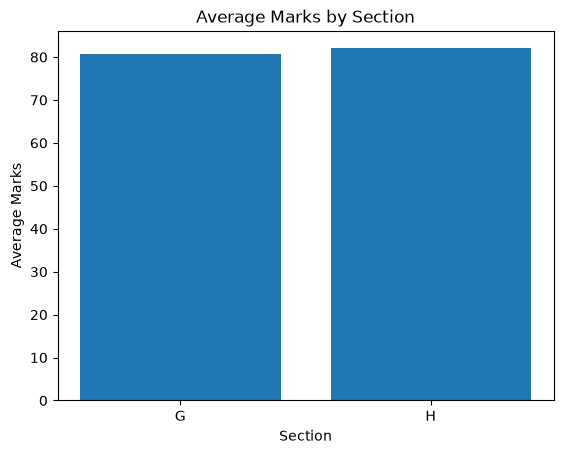

In [24]:
students = pd.DataFrame({
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman", "Maha"],
    "section": ["G", "G", "H", "H", "G", "H"],
    "marks": [78, 91, 67, 84, 73, 95]
})

section_avg = students.groupby("section")["marks"].mean()

plt.bar(section_avg.index, section_avg.values)
plt.xlabel("Section")
plt.ylabel("Average Marks")
plt.title("Average Marks by Section")
plt.show()

## Q24 — Histogram of marks

A histogram shows how the marks are distributed across ranges. The data below has most students around the middle-to-high mark ranges.

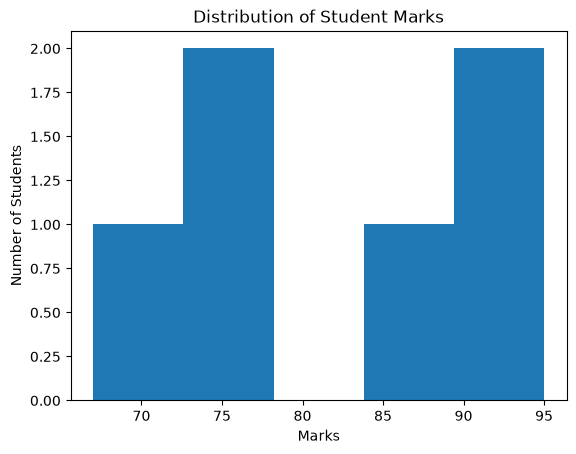

The marks are spread across several ranges, with most students in the higher mark ranges.


In [25]:
students = pd.DataFrame({
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman", "Maha"],
    "section": ["G", "G", "H", "H", "G", "H"],
    "marks": [78, 91, 67, 84, 73, 95]
})

marks = students["marks"]

plt.hist(marks, bins=5)
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Marks")
plt.show()

print("The marks are spread across several ranges, with most students in the higher mark ranges.")

## Q25 — 1x2 subplot

I use two subplots in one figure: a line plot for a simple trend and a scatter plot to compare two numeric columns.

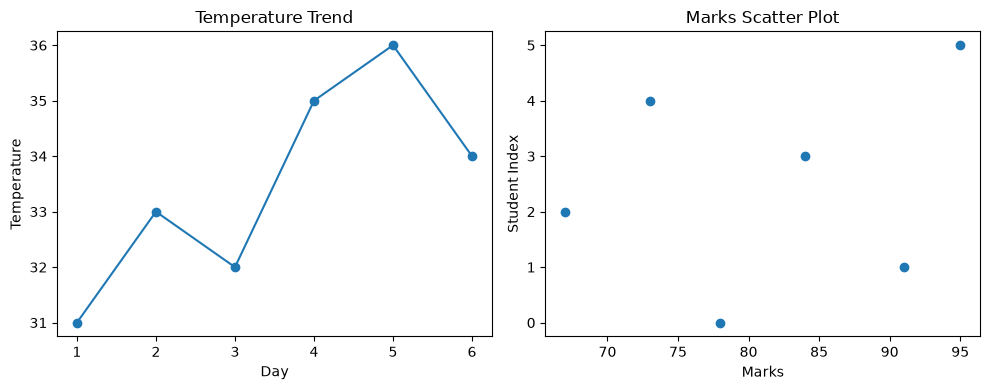

In [26]:
students = pd.DataFrame({
    "name": ["Ali", "Sara", "Omar", "Hina", "Usman", "Maha"],
    "section": ["G", "G", "H", "H", "G", "H"],
    "marks": [78, 91, 67, 84, 73, 95]
})

days = [1, 2, 3, 4, 5, 6]
temperature = [31, 33, 32, 35, 36, 34]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(days, temperature, marker="o")
axes[0].set_title("Temperature Trend")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Temperature")

axes[1].scatter(students["marks"], range(len(students)))
axes[1].set_title("Marks Scatter Plot")
axes[1].set_xlabel("Marks")
axes[1].set_ylabel("Student Index")

plt.tight_layout()
plt.show()